<a href="https://colab.research.google.com/github/kdkim2000/RAG2026/blob/main/%5B%EA%B0%95%EC%9D%98%EB%82%B4%EC%9A%A9%5D_9_Code_Interpreter%EB%A5%BC_%EC%9D%B4%EC%9A%A9%ED%95%9C_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EC%8B%9C%EA%B0%81%ED%99%94%EC%99%80_Skill.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [실습] Code Interpreter를 이용한 데이터 시각화와 Skill

최근의 에이전트에게 가장 중요한 도구는 CLI 터미널 도구입니다.  

CLI 터미널 도구의 활용 방법을 이해하고, 이와 함께 최근 주목받고 있는 Skill에 대해서도 알아보겠습니다.

In [ ]:
!pip install openai matplotlib langchain langchain-google-genai langchain-openai langchain-community langchain-experimental langchain-tavily langgraph -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.8/72.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.1/122.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 7.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [ ]:
# 한국어 시각화 라이브러리
!pip install koreanize_matplotlib -q
# Python 3.13 이후에는 setuptools 라이브러리를 같이 설치해주세요

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 59.0 MB/s eta 0:00:00


TAVILY API KEY와 OPENAI API KEY가 포함된 .env 파일을 업로드하고,    
환경 변수를 등록합니다.

In [ ]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

load_dotenv(override=True)

llm = ChatOpenAI(model = 'gpt-5.2', reasoning_effort='low')

## CLI 도구 연결하기   

최근 에이전트의 흐름은 여러 개의 도구를 연결하는 대신,   
터미널 CLI 도구를 연결하고 예시 스크립트를 전달하는 방법으로 변화하고 있습니다.

### 셸 도구의 안전 경계   

셸 도구는 임의의 명령을 실행할 수 있으므로, 다른 도구에 걸어 둔 제약을 우회하는 통로가 됩니다.   
파일 읽기 도구에 차단 목록을 지정하더라도, 셸이 열려 있으면 같은 파일을 터미널 명령으로 읽을 수 있습니다.   

따라서 셸 도구에는 최소한 다음 세 가지를 적용합니다.   

- 비밀 정보 파일 차단: 명령어에 `.env`, `credentials`, `id_rsa` 등이 포함되면 실행하지 않습니다.
- 위험 명령 차단: 재귀 삭제, 디스크 포맷, 권한 상승, 내려받은 스크립트의 즉시 실행을 막습니다.
- 실행 위치 고정: `cwd`를 지정해 작업 디렉터리 안에서만 명령이 실행되도록 합니다.

문자열 패턴 검사는 표현을 바꾸면 통과할 수 있어, 이것만으로 완전한 격리가 되지는 않습니다.   
운영 환경에서는 컨테이너, 별도 실행 계정, 읽기 전용 마운트처럼 운영체제 수준의 격리를 함께 사용합니다.   

In [ ]:
from langchain_core.tools import tool
from pathlib import Path
import os, re, subprocess

WORKSPACE = Path.cwd().resolve()

# 명령어 문자열에 등장하면 실행을 막을 비밀 정보 파일
BLOCKED_FILES = ['.env', 'credentials', '.secret', 'id_rsa', '.pem']

# 되돌릴 수 없거나 권한을 넘기는 명령 패턴
BLOCKED_PATTERNS = [
    r'\brm\s+-[a-z]*[rf]',          # rm -rf
    r'\b(del|rmdir)\s+/[sqf]',      # Windows 재귀 삭제
    r'\b(format|mkfs|fdisk)\b',
    r'\b(shutdown|reboot)\b',
    r'\b(sudo|su)\s',
    r'(^|[\s/\\])env(\s|$)',        # env 파일 직접 참조
    r'>\s*/dev/[sh]d',              # 디스크에 직접 쓰기
    r'\b(curl|wget)\b[^|]*\|\s*(ba)?sh',   # 내려받은 스크립트 즉시 실행
]


def check_command(command: str) -> str | None:
    """차단 사유를 반환합니다. 실행해도 되는 명령이면 None을 반환합니다."""
    lowered = command.lower()
    for name in BLOCKED_FILES:
        if name in lowered:
            return f"비밀 정보 파일({name})에 접근하는 명령입니다."
    for pattern in BLOCKED_PATTERNS:
        if re.search(pattern, lowered):
            return f"위험한 명령 패턴({pattern})이 포함되어 있습니다."
    return None


@tool
def run_command(command: str, timeout:int=60) -> str:
    """터미널 명령어를 실행합니다. command: 실행할 셸 명령어"""
    reason = check_command(command)
    if reason:
        return f'[차단] {reason}'
    try:
        r = subprocess.run(command, shell=True, capture_output=True, text=True,
                           timeout=timeout, cwd=WORKSPACE)
        out = r.stdout + (f"\n[STDERR] {r.stderr}" if r.returncode != 0 else '')
        return out.strip() or '(완료, 출력 없음)'
    except Exception as e:
        return f'오류: {e}'

In [ ]:
# 현재 폴더 검색
run_command.invoke('ls')

'sample_data\nsample_data.csv\nskills.zip'

In [ ]:
# 임의의 파이썬  스크립트 실행
run_command.invoke({"command": 'python -c "print(1+2)"'})

'3'

에이전트가 다룰 예시 데이터를 확인해 보겠습니다.

In [ ]:
import pandas as pd
df = pd.read_csv('./sample_data.csv')
df.head()


,날짜,제품,가격,판매량,고객_연령,고객_성별,지역
0,2023-01-01,노트북,1200000,5,34,남성,서울
1,2023-01-02,노트북,1200000,3,42,여성,부산
2,2023-01-03,노트북,1200000,2,28,남성,대구
3,2023-01-04,노트북,1200000,7,45,여성,인천
4,2023-01-05,노트북,1200000,4,31,남성,광주


정의한 셸 도구를 LangChain Agent에 연결합니다.  
체크포인터로 InMemorySaver를 전달하면 thread_id 단위로 대화가 이어집니다.

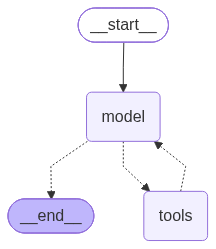

In [ ]:
from langchain.agents import create_agent
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

tools = [run_command]

system_prompt = '''당신은 파이썬 코드를 이용한 데이터 분석의 전문가입니다.
툴을 사용하기 전에는 중간 단계를 간략하게 설명하세요.
한국어 시각화를 다루는 경우, koreanize_matplotlib을 항상 import하세요.
'''

agent = create_agent(llm, tools=tools, system_prompt=system_prompt, checkpointer=InMemorySaver())

config = {'configurable': {'thread_id': 'cli-agent'}}

agent

In [ ]:
question = "파일의 위치가 ./sample_data.csv 이다. 이 파일의 제품별 판매량을 비교하여 result.png에 시각화해줘."

# 깔끔하게 스트리밍
for chunk in agent.stream({'messages':[HumanMessage(question)]}, config=config, stream_mode="updates"):
    for step, data in chunk.items():
        print(f"step: {step}")
        result = data['messages'][-1].text
        if len(result) > 1000:
            print(f"    content: {result[0:200] } (중략)")
        else:
            print(f"    content: {result}")

        if step=='model':
            print("T.C:", data['messages'][-1].tool_calls)
        print('-------------')

step: model
    content: 먼저 (1) CSV를 불러와 컬럼을 확인한 뒤, (2) ‘제품’(또는 이에 해당하는 컬럼) 기준으로 판매량을 집계하고, (3) 막대그래프로 저장하겠습니다.
T.C: [{'name': 'run_command', 'args': {'command': "python - <<'PY'\nimport pandas as pd\npath='./sample_data.csv'\ndf=pd.read_csv(path)\nprint(df.head())\nprint('columns:', list(df.columns))\nprint(df.dtypes)\nPY"}, 'id': 'call_zYJpiYUGUAeub9fzuzPmWyVW', 'type': 'tool_call'}]
-------------
step: tools
    content: 날짜   제품       가격  판매량  고객_연령 고객_성별  지역
0  2023-01-01  노트북  1200000    5     34    남성  서울
1  2023-01-02  노트북  1200000    3     42    여성  부산
2  2023-01-03  노트북  1200000    2     28    남성  대구
3  2023-01-04  노트북  1200000    7     45    여성  인천
4  2023-01-05  노트북  1200000    4     31    남성  광주
columns: ['날짜', '제품', '가격', '판매량', '고객_연령', '고객_성별', '지역']
날짜       object
제품       object
가격        int64
판매량       int64
고객_연령     int64
고객_성별    object
지역       object
dtype: object
-------------
step: model
    content: 컬럼에 ‘제품’, ‘판매량’이 있으니 제품별로 판매량 합계를 구해 내림차순으로 정렬한 뒤, 한국어 폰트 설

LLM에 여러 개의 툴을 연결하는 경우, 컨텍스트가 길어지는 문제가 발생합니다.    
이를 해결하기 위한 방법으로, Skill(스킬)이 주목받고 있습니다.

## Skill(스킬)

스킬의 핵심 메커니즘은 '점진적 공개'입니다.   
복잡한 작업을 수행해야 하거나, 연결된 도구가 많아지면 컨텍스트가 증가하는 문제를 해결합니다.   

스킬은 `SKILL.md` 파일로 정의하며, YAML frontmatter(메타데이터)와 Markdown body(지침)로 구성됩니다.

```yaml
---
name: skill-name              # 스킬 식별자 (소문자, 하이픈)
description: 한 줄 설명         # 에이전트의 자동 호출 판단에 사용
metadata:
  type: cli-tool               # cli-tool | prompt-bundle | file-template
---

Markdown 본문: DB 스키마, 비즈니스 로직, 스크립트 사용법 등
```


skills.zip의 압축을 풀고, 예시 스킬을 확인해 보겠습니다.

In [ ]:
import zipfile
import os

def unzip_file(zip_file_path, extract_path='./'):
    """
    zip 파일을 지정된 경로에 압축 해제합니다.

    Args:
        zip_file_path (str): 압축 해제할 zip 파일의 경로.
        extract_path (str): 압축을 해제할 디렉토리 경로. 기본값은 현재 디렉토리.
    """
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print(f"'{zip_file_path}' 파일이 '{extract_path}'에 성공적으로 압축 해제되었습니다.")
    except zipfile.BadZipFile:
        print(f"오류: '{zip_file_path}'은 유효한 zip 파일이 아닙니다.")
    except FileNotFoundError:
        print(f"오류: '{zip_file_path}' 파일을 찾을 수 없습니다.")
    except Exception as e:
        print(f"압축 해제 중 오류 발생: {e}")

unzip_file('skills.zip')


'skills.zip' 파일이 './'에 성공적으로 압축 해제되었습니다.


---
## 2. 스킬 폴더 구조

```
skills/
├── sales_analytics/           ← CLI Tool: 매출 DB 스키마 + 쿼리 스크립트
│   ├── SKILL.md               (YAML frontmatter + 테이블 구조, 비즈니스 로직)
│   ├── setup.py               (SQLite 샘플 데이터 생성)
│   └── query.py               (SQL 쿼리 실행 유틸리티)
├── inventory_management/      ← CLI Tool: 재고 DB 스키마 + 쿼리 스크립트
│   ├── SKILL.md
│   ├── setup.py
│   └── query.py
└── customer_report/           ← Prompt Bundle + File Template
    ├── SKILL.md               (보고서 작성 가이드라인, 스타일 규칙)
    └── generate.py            (매출/재고 DB 연계 보고서 생성)

(+ 2개의 추가 스킬)
```

각 폴더의 `SKILL.md`는 Agent Skills 표준을 따릅니다:

```yaml
---
name: sales-analytics                    # 스킬 식별자
description: 매출 데이터 분석을 위한 ...    # scan_skills()가 파싱하여 시스템 프롬프트에 주입
metadata:
  type: cli-tool
---

## Tables                                # Markdown 본문: 상세 도메인 지식
### customers
| 컬럼 | 타입 | 설명 |
...
```

위 내용 중, 프론트매터에 해당하는 부분만 최초 에이전트에 연결됩니다.   

이후, 에이전트가 해당 스킬이 필요할 때 스킬의 전체 내용을 로드하는 방식입니다.

In [ ]:
import yaml
from pathlib import Path

SKILLS_DIR = Path("skills")


def scan_skills(skills_dir: Path = SKILLS_DIR) -> dict[str, dict]:
    """SKILL.md의 YAML frontmatter를 파싱하여 {name: {description, path, meta, body}} 딕셔너리를 반환합니다."""
    skills = {}
    if not skills_dir.exists():
        return skills
    for d in sorted(skills_dir.iterdir()):
        if not d.is_dir():
            continue
        skill_file = d / "SKILL.md"
        if not skill_file.exists():
            continue
        content = skill_file.read_text(encoding="utf-8")
        # --- frontmatter --- 파싱
        if not content.startswith("---"):
            continue
        parts = content.split("---", 2)
        if len(parts) < 3:
            continue
        meta = yaml.safe_load(parts[1])
        body = parts[2].strip()
        name = meta.get("name", d.name)
        skills[name] = {
            "name": name,
            "description": meta.get("description", ""),
            "path": str(d),
            "folder": d.name,
            "meta": meta,
            "body": body,
        }
    return skills


def format_skill_list(skills: dict[str, dict]) -> str:
    """스킬 목록을 이름, 타입, 설명 한 줄씩으로 정리합니다."""
    lines = [f"사용 가능한 스킬 {len(skills)}개:"]
    for name, s in skills.items():
        skill_type = s["meta"].get("metadata", {}).get("type", "unknown")
        lines.append(f"  - {name} [{skill_type}]: {s['description']}")
    return "\n".join(lines)


print(format_skill_list(scan_skills()))

사용 가능한 스킬 5개:
  - customer-report [prompt-bundle]: 고객 분석 보고서 생성 가이드라인과 마크다운 템플릿 (매출 DB + 재고 DB 연계 분석)
  - inventory-management [cli-tool]: 재고 관리를 위한 DB 스키마와 SQL 쿼리 스크립트 (products, warehouses, inventory, stock_movements 테이블)
  - sales-analytics [cli-tool]: 매출 데이터 분석을 위한 DB 스키마와 SQL 쿼리 스크립트 (customers, orders, order_items 테이블)
  - skill-creator [unknown]: Create new skills, modify and improve existing skills, and measure skill performance. Use when users want to create a skill from scratch, edit, or optimize an existing skill, run evals to test a skill, benchmark skill performance with variance analysis, or optimize a skill's description for better triggering accuracy.
  - web-search [cli-tool]: Tavily 웹 검색(카테고리/시간범위/도메인 필터/원본본문 등 전체 옵션)과 URL 본문 추출(fetch_url) 스크립트. 최신 정보 조회, 외부 문서 정독, 실시간 뉴스/금융/리서치에 사용


스킬을 불러오기 위한 기본 도구를 구성합니다.      
skill_name을 통해 스킬의 상세 내용에 접근하고, 이를 컨텍스트에 추가합니다.

load_skill은 호출될 때마다 skills/를 다시 읽으므로, 스킬을 추가하면 도구는 곧바로 인식합니다.

In [ ]:
@tool
def load_skill(skill_name: str) -> str:
    """스킬의 상세 내용(SKILL.md body)을 로드합니다. 해당 도메인의 작업을 수행하기 전에 호출하세요.

    Args:
        skill_name: 로드할 스킬 이름
    """
    skills = scan_skills()      # 호출 시점의 skills/ 상태를 그대로 읽습니다
    if skill_name not in skills:
        return f"스킬 '{skill_name}'을 찾을 수 없습니다. 사용 가능: {', '.join(skills)}"

    skill = skills[skill_name]
    body = skill["body"]

    # 스킬 폴더의 파이썬 스크립트를 실행 명령과 함께 덧붙입니다.
    scripts = [f.name for f in Path(skill["path"]).iterdir() if f.is_file() and f.suffix == ".py"]
    if scripts:
        body += "\n\n## 실행 가능한 스크립트\n"
        for s in scripts:
            body += f"- `{skill['folder']}/{s}` → `python skills/{skill['folder']}/{s}`\n"

    return body

In [ ]:
load_skill.invoke("customer-report")

'## 보고서 구조\n\n보고서는 반드시 아래 섹션 순서를 따릅니다:\n\n1. **요약 (Executive Summary)** -- 핵심 지표 3~5개, 한 문단\n2. **매출 분석** -- 기간별 매출 추이, 지역별/등급별 분포\n3. **고객 분석** -- 활성 고객 수, CLV 상위 고객, 이탈 위험 고객\n4. **재고 현황** -- 재주문 필요 상품, 창고별 재고 분포\n5. **권장 액션** -- 데이터 기반 구체적 제안 3~5개\n\n## 스타일 규칙\n\n- 수치에는 반드시 단위 표기 (원, 건, 명)\n- 금액은 천 단위 쉼표 사용 (예: 1,234,000원)\n- 비율은 소수점 1자리까지 (예: 23.5%)\n- 차트/테이블 포함 시 캡션 필수\n- 파일명: `report_YYYYMMDD_주제.md`\n\n## Scripts\n\n- `generate.py` -- 매출/재고 DB에서 데이터를 읽어 보고서 초안 생성\n  - Usage: `python generate.py --type summary`\n  - Options: `--type summary|sales|inventory|full`\n\n## 실행 가능한 스크립트\n- `customer_report/generate.py` → `python skills/customer_report/generate.py`\n'

2개의 툴과 함께 사용할 기본 파일 시스템 도구를 추가하고, 에이전트를 구성합니다.

In [ ]:
import os
from pathlib import Path
from langchain.tools import tool

# 이름이 일치하거나 확장자가 일치하면 접근을 막을 파일
BLOCKED_FILENAMES = ['env', '.env', 'credentials', '.secret', 'id_rsa', '.pem']


def is_blocked_name(file_path: str) -> bool:
    """파일 이름이 차단 목록에 해당하는지 확인합니다."""
    base = os.path.basename(file_path)
    return base in BLOCKED_FILENAMES or any(file_path.endswith(b) for b in BLOCKED_FILENAMES)


def safe_path(p: str) -> Path:
    """작업 디렉터리(WORKSPACE) 안의 경로로 정규화합니다.
    realpath로 상위 경로 참조와 심볼릭 링크까지 해소한 뒤 비교합니다."""
    target = Path(os.path.realpath(WORKSPACE / p))
    try:
        inside = os.path.commonpath([str(WORKSPACE), str(target)]) == str(WORKSPACE)
    except ValueError:      # 서로 다른 드라이브라 비교할 수 없는 경우
        inside = False
    if not inside:
        raise ValueError(f'작업 디렉터리 밖 경로 접근 불가: {p}')
    return target


@tool
def read_file(file_path: str) -> str:
    """파일 내용을 읽습니다. file_path: 파일 경로"""
    if is_blocked_name(file_path):
        return f"보안 정책에 의해 '{os.path.basename(file_path)}' 파일은 읽을 수 없습니다."
    try:
        text = safe_path(file_path).read_text(encoding='utf-8')
        return text[:10000] + ('\n... (truncated)' if len(text) > 10000 else '')
    except Exception as e:
        return f'파일 읽기 오류: {e}'


@tool
def write_file(file_path: str, content: str) -> str:
    """파일에 내용을 작성. file_path: 경로, content: 작성할 내용"""
    if is_blocked_name(file_path):
        return f"보안 정책에 의해 '{os.path.basename(file_path)}' 파일은 쓸 수 없습니다."
    try:
        target = safe_path(file_path)
        target.parent.mkdir(parents=True, exist_ok=True)
        target.write_text(content, encoding='utf-8')
        return f'파일 작성 완료: {file_path} ({len(content)}자)'
    except Exception as e:
        return f'파일 작성 오류: {e}'


@tool
def list_files(path: str = ".") -> str:
    """디렉터리의 파일/하위 폴더 목록을 반환합니다.

    Args:
        path: 작업 디렉터리 기준 상대 경로 (기본값: 현재 디렉터리)
    """
    try:
        target = safe_path(path)
        if not target.is_dir():
            return f"[ERROR] 디렉터리가 아님: {path}"
        entries = sorted(p.name + ("/" if p.is_dir() else "") for p in target.iterdir())
        return "\n".join(entries) if entries else "(empty)"
    except Exception as e:
        return f"[ERROR] {e}"


tools = [load_skill, run_command, read_file, write_file, list_files]

프론트매터 목록을 시스템 프롬프트에 추가해 에이전트를 만듭니다.  

In [ ]:
agent = create_agent(
    llm, tools=tools,
    system_prompt=f"""도구를 활용할 때마다, 중간 과정을 간략히 설명하세요.
{format_skill_list(scan_skills())}""",
    checkpointer=InMemorySaver(),
)

skill_config = {'configurable': {'thread_id': 'skill-agent'}}

In [ ]:
def stream_agent(agent, input_msgs, config=None):
    """에이전트 실행을 스트리밍하며 각 스텝을 출력합니다."""
    def _format_arg(v):
        s = repr(v) if not isinstance(v, str) else v
        return s if len(s) <= 200 else s[:197] + "..."

    last_msg = None
    for chunk in agent.stream(input_msgs, config=config, stream_mode="updates"):
        for step, data in chunk.items():
            msg = data['messages'][-1]
            content = msg.text if hasattr(msg, 'text') else str(msg.content)
            print(f"[{step}]")
            if len(content) > 1000:
                print(f"  content: {content[:800]}...(중략)")
            else:
                print(f"  content: {content}")
            if hasattr(msg, 'tool_calls') and msg.tool_calls:
                calls = []
                for tc in msg.tool_calls:
                    args_str = ", ".join(f"{k}={_format_arg(v)}" for k, v in tc['args'].items())
                    calls.append(f"{tc['name']}({args_str})")
                print(f"  tool_calls: {calls}")
            print()
            last_msg = msg
    return last_msg


In [ ]:
result = stream_agent(agent,
    {"messages": [{"role": "user", "content": "지역별 매출 현황을 분석해줘. 가장 매출이 높은 지역과 낮은 지역을 비교해줘."}]},
    config=skill_config,
)

[model]
  content: 
  tool_calls: ['load_skill(skill_name=sales-analytics)']

[tools]
  content: ## Tables

### customers
| 컬럼 | 타입 | 설명 |
|------|------|------|
| customer_id | INTEGER PK | 고객 ID |
| name | TEXT | 고객명 |
| email | TEXT | 이메일 |
| signup_date | DATE | 가입일 |
| status | TEXT | active / inactive |
| customer_tier | TEXT | bronze / silver / gold / platinum |

### orders
| 컬럼 | 타입 | 설명 |
|------|------|------|
| order_id | INTEGER PK | 주문 ID |
| customer_id | INTEGER FK | 고객 ID |
| order_date | DATE | 주문일 |
| status | TEXT | pending / completed / cancelled / refunded |
| total_amount | REAL | 총 금액 |
| sales_region | TEXT | north / south / east / west |

### order_items
| 컬럼 | 타입 | 설명 |
|------|------|------|
| item_id | INTEGER PK | 항목 ID |
| order_id | INTEGER FK | 주문 ID |
| product_id | INTEGER | 상품 ID |
| quantity | INTEGER | 수량 |
| unit_price | REAL | 단가 |
| discount_per...(중략)

[model]
  content: 
  tool_calls: ['run_command(command=python skills/sales_analytics/query.py

In [ ]:
# 최종 결과 확인
print(result.text)

매출 DB(`orders`)에서 **status='completed'** 주문의 `total_amount`를 지역(`sales_region`)별로 합산해 지역별 매출을 집계한 뒤, **최고/최저 매출 지역을 비교**했습니다. (쿼리로 지역별 합계/주문수/AOV를 계산 → 최대/최소 지역을 추출해 격차 산출)

## 지역별 매출 현황 (Completed 기준)
| 지역 | 완료 주문수 | 매출(합계) | 평균 주문금액(AOV) |
|---|---:|---:|---:|
| west | 27 | 57,311,400 | 2,122,644 |
| east | 25 | 50,193,035 | 2,007,721 |
| south | 26 | 41,015,410 | 1,577,516 |
| north | 18 | 31,494,440 | 1,749,691 |

## 최고 매출 vs 최저 매출 지역 비교
- **최고 매출 지역:** west (57,311,400 / 27건 / AOV 2,122,644)
- **최저 매출 지역:** north (31,494,440 / 18건 / AOV 1,749,691)

### 격차 요약
- **매출 격차:** 25,816,960 (west가 더 큼)
- **매출 비율:** west가 north의 **약 1.82배**
- **주문수 격차:** +9건 (27건 vs 18건)
- **AOV 격차:** +372,953 (west가 더 큼)

원하시면 기간(월/분기)별로 나눠서 지역 순위가 어떻게 변하는지, 또는 지역 매출 차이가 “주문수 차이” 때문인지 “AOV 차이” 때문인지 분해해서도 보여드릴게요.


In [ ]:
result2 = stream_agent(agent,
    {"messages": [{"role": "user", "content": "전체 매출과 재고 현황을 포함한 종합 보고서를 생성해줘. 보고서 가이드라인을 따라서 작성해."}]},
    config=skill_config,
)

[model]
  content: 
  tool_calls: ['load_skill(skill_name=customer-report)', 'load_skill(skill_name=inventory-management)', 'load_skill(skill_name=sales-analytics)']

[tools]
  content: ## 보고서 구조

보고서는 반드시 아래 섹션 순서를 따릅니다:

1. **요약 (Executive Summary)** -- 핵심 지표 3~5개, 한 문단
2. **매출 분석** -- 기간별 매출 추이, 지역별/등급별 분포
3. **고객 분석** -- 활성 고객 수, CLV 상위 고객, 이탈 위험 고객
4. **재고 현황** -- 재주문 필요 상품, 창고별 재고 분포
5. **권장 액션** -- 데이터 기반 구체적 제안 3~5개

## 스타일 규칙

- 수치에는 반드시 단위 표기 (원, 건, 명)
- 금액은 천 단위 쉼표 사용 (예: 1,234,000원)
- 비율은 소수점 1자리까지 (예: 23.5%)
- 차트/테이블 포함 시 캡션 필수
- 파일명: `report_YYYYMMDD_주제.md`

## Scripts

- `generate.py` -- 매출/재고 DB에서 데이터를 읽어 보고서 초안 생성
  - Usage: `python generate.py --type summary`
  - Options: `--type summary|sales|inventory|full`

## 실행 가능한 스크립트
- `customer_report/generate.py` → `python skills/customer_report/generate.py`


[tools]
  content: ## Tables

### products
| 컬럼 | 타입 | 설명 |
|------|------|------|
| product_id | INTEGER PK | 상품 ID |
| product_name | TEXT | 상품명 |
| sku | TEXT | SKU

In [ ]:
# 최종 결과 확인
print(result2.text)

매출 DB(`sales.db`)와 재고 DB(`inventory.db`)를 각각 SQL로 집계한 뒤, **보고서 가이드라인(섹션 순서/단위/표 캡션)**에 맞춰 마크다운 보고서를 생성해 파일로 저장했습니다.

- 생성 파일: **`report_20260804_종합_매출_재고.md`**

아래는 보고서 본문입니다(동일 내용이 파일에도 저장됨).

---

# 종합 보고서: 전체 매출 및 재고 현황

> 생성일: 2026-08-04  
> 데이터 소스: `sales.db(orders/customers)` + `inventory.db(products/warehouses/inventory)`  
> 매출 집계 기준: `orders.status='completed'`의 `total_amount` 합산 (할인 반영 완료)

## 1. 요약 (Executive Summary)
- 분석 기간 매출은 **180,014,285원(완료 주문 96건)**이며, 지역별로는 **west 57,311,400원**이 최대, **north 31,494,440원**이 최소입니다.
- 고객 측면에서는 **활성 고객 16명**(조건: active & 가입 90일 경과)이며, CLV 상위 1위 고객은 **전예린(gold) 20,902,030원**입니다.
- 재고는 **총 재고 가치 25,016,000원**(단종 제외)이며, 창고 가동률은 **대전 28.2% > 부산 18.1% > 서울 12.5%** 순입니다.
- 현재 데이터 기준 **재주문 필요(reorder_point 이하) 상품은 0개**로 탐지되었습니다.

## 2. 매출 분석

### 2.1 기간 개요
- 기간: **2024-01-02 ~ 2025-05-04**
- 완료 주문: **96건**
- 총 매출: **180,014,285원**

**[표 1] 월별 매출 추이 (Completed 기준)**
| 월(YYYY-MM) | 완료 주문(건) | 매출(원) |
|---|---:|---:|
| 2024-01 | 11 | 22,941,580원 |

---
## [실습] 다양한 스킬 사용하기

실습에서 다루지 않은 스킬들도 프롬프트를 통해 실행해 보세요.

새로운 스킬을 추가하고, Agent로 테스트해보세요.

1. `skills/` 아래에 새 폴더 생성
2. `SKILL.md` 작성 (YAML frontmatter 형식):
3. 부가적인 파일 작성

- Skill Creator Skill를 사용해서 새로운 스킬을 만들 수 있습니다.

In [ ]:
agent = create_agent(
    llm, tools=tools,
    system_prompt=f"""도구를 활용할 때마다, 중간 과정을 간략히 설명하세요.
{format_skill_list(scan_skills())}""",
    checkpointer=InMemorySaver(),
)

skill_config = {'configurable': {'thread_id': 'skill-agent'}}

In [ ]:
result = stream_agent(agent,
    {"messages": [{"role": "user", "content": """
지역별 현재 시간을 초단위로 알려주는
파이썬 스크립트 기반의 'clock' 스킬을 만들어줘.
스킬 설명은 최대한 간략하게 하고.
기본값은 서울.
스킬 잘 만들어졌는지 테스트도 해줘.
"""}]},
    config=skill_config,
)

[model]
  content: 
  tool_calls: ['list_files(path=.)']

[tools]
  content: .config/
.env
report_20260804_종합_매출_재고.md
result.png
sample_data.csv
sample_data/
skills.zip
skills/

[model]
  content: 
  tool_calls: ['list_files(path=skills)']

[tools]
  content: customer_report/
inventory_management/
sales_analytics/
skill-creator/
web_search/

[model]
  content: 
  tool_calls: ['load_skill(skill_name=skill-creator)']

[tools]
  content: # Skill Creator

A skill for creating new skills and iteratively improving them.

At a high level, the process of creating a skill goes like this:

- Decide what you want the skill to do and roughly how it should do it
- Write a draft of the skill
- Create a few test prompts and run claude-with-access-to-the-skill on them
- Help the user evaluate the results both qualitatively and quantitatively
  - While the runs happen in the background, draft some quantitative evals if there aren't any (if there are some, you can either use as is or modify if you feel

In [ ]:
agent = create_agent(
    llm, tools=tools,
    system_prompt=f"""도구를 활용할 때마다, 중간 과정을 간략히 설명하세요.
{format_skill_list(scan_skills())}""",
    checkpointer=InMemorySaver(),
)

skill_config = {'configurable': {'thread_id': 'skill-agent'}}

In [ ]:
result = stream_agent(agent,
    {"messages": [{"role": "user", "content": """
오후 6시까지 몇 초 남았니?
"""}]},
    config=skill_config,
)

[model]
  content: 
  tool_calls: ['load_skill(skill_name=clock)']

[tools]
  content: ## What this skill does
- 사용자가 지역/도시/타임존을 주면 현재 시간을 **초 단위까지** 출력한다.
- 입력이 없으면 **서울(Asia/Seoul)** 을 기본으로 한다.

## How to use
1) 사용자가 준 지역 문자열을 IANA 타임존으로 해석한다.
- 이미 `Area/City` 형태면 그대로 사용.
- 흔한 별칭은 아래 매핑을 우선 적용.
- 모르면 사용 가능한 후보를 3개 이내로 제시하고 재질문.

2) `scripts/clock.py` 를 실행해 현재 시간을 구한다.
- 여러 지역이면 한 번에 계산해 표로 출력한다.

## Alias mapping (minimal)
- 서울, 한국, KST, Seoul, Korea → `Asia/Seoul`
- 도쿄, Tokyo, JST → `Asia/Tokyo`
- 뉴욕, New York, ET, EST, EDT → `America/New_York`
- 런던, London, UK, BST, GMT → `Europe/London`
- 로스앤젤레스, LA, Los Angeles, PT, PST, PDT → `America/Los_Angeles`

## Output format
- 간단한 마크다운 표로만 출력:

| Location | Timezone | Current time (YYYY-MM-DD HH:MM:SS) |
|---|---|---|

(필요하면 마지막 줄에 `Generated at: <UTC timestamp>` 를 1줄로 덧붙인다.)

[model]
  content: 
  tool_calls: ['run_command(command=python scripts/clock.py Asia/Seoul)']

[tools]
  content: [STDERR] python3: can't open file '/content/script